In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import warnings

In [26]:
print("="*60)
print("CREDIT RISK DATASET EXPLORATION")
print("="*60)


df = pd.read_csv('loan_risk_prediction_dataset.csv')

print("\nBASIC INFORMATION:")
print(f"Shape: {df.shape}")
print(f"\nColumn Info:")
print(df.info())

print("\n FIRST 5 ROWS:")
print(df.head())

print("\nLAST 5 ROWS:")
print(df.tail())

print("\n DESCRIPTIVE STATISTICS:")
print(df.describe())

CREDIT RISK DATASET EXPLORATION

BASIC INFORMATION:
Shape: (5000, 10)

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB
None

 FIRST 5 ROWS:
   Age   Income  LoanAmount  CreditScore  YearsExperience  Gender  \
0   56  48353.0     31258.0        675.0               20  Female   
1   69  57462.0     23262.0       

In [27]:
print("\n📊 MISSING VALUES:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

print("\n📊 TARGET VARIABLE DISTRIBUTION:")
print(df['LoanApproved'].value_counts())
print(f"\nApproval Rate: {df['LoanApproved'].mean()*100:.2f}%")



📊 MISSING VALUES:
             Missing  Percentage
Income           196        3.92
CreditScore      194        3.88
Education        198        3.96

📊 TARGET VARIABLE DISTRIBUTION:
LoanApproved
0    3849
1    1151
Name: count, dtype: int64

Approval Rate: 23.02%


In [28]:
print("\n" + "="*60)
print("DATA CLEANING")
print("="*60)

df_clean = df.copy()

# Fixing negative LoanAmount (take absolute value)
neg_loans = (df_clean['LoanAmount'] < 0).sum()
print(f"\nNegative loan amounts found: {neg_loans}")
df_clean['LoanAmount'] = df_clean['LoanAmount'].abs()

# Converting numeric columns and handle missing values
numeric_cols = ['Income', 'CreditScore', 'YearsExperience']
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
    missing_count = df_clean[col].isnull().sum()
    if missing_count > 0:
        print(f"Missing values in {col}: {missing_count} ({missing_count/len(df)*100:.1f}%)")
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

# Cap extreme outliers (99th percentile)
for col in ['Income', 'LoanAmount']:
    cap = df_clean[col].quantile(0.99)
    outliers = (df_clean[col] > cap).sum()
    if outliers > 0:
        print(f"Capping {outliers} outliers in {col} at {cap:,.0f}")
        df_clean[col] = np.where(df_clean[col] > cap, cap, df_clean[col])

# Fixing YearsExperience > Age
invalid_exp = (df_clean['YearsExperience'] > df_clean['Age']).sum()
if invalid_exp > 0:
    print(f"Fixing {invalid_exp} rows where Experience > Age")
    df_clean['YearsExperience'] = np.where(
        df_clean['YearsExperience'] > df_clean['Age'],
        df_clean['Age'] - 6,
        df_clean['YearsExperience']
    )
    df_clean['YearsExperience'] = df_clean['YearsExperience'].clip(lower=0)

# Filling missing Education with mode
if df_clean['Education'].isnull().sum() > 0:
    mode_edu = df_clean['Education'].mode()[0]
    print(f"Filling missing Education with mode: {mode_edu}")
    df_clean['Education'].fillna(mode_edu, inplace=True)

# Filling empty strings in categorical columns
categorical_cols = ['Gender', 'Education', 'City', 'EmploymentType']
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')
    df_clean[col] = df_clean[col].replace('', 'Unknown')

print("\n✅ Data cleaning complete!")
print(f"New shape: {df_clean.shape}")


DATA CLEANING

Negative loan amounts found: 28
Missing values in Income: 196 (3.9%)
Missing values in CreditScore: 194 (3.9%)
Capping 50 outliers in Income at 84,110
Capping 50 outliers in LoanAmount at 38,260
Fixing 574 rows where Experience > Age
Filling missing Education with mode: Bachelors

✅ Data cleaning complete!
New shape: (5000, 10)


In [29]:
print("\n" + "="*60)
print("FEATURE ENGINEERING")
print("="*60)

# Creating new features
df_clean['DebtToIncome'] = df_clean['LoanAmount'] / (df_clean['Income'] + 1)
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=[0, 25, 35, 50, 65, 100], 
                               labels=['18-25', '26-35', '36-50', '51-65', '65+'])
df_clean['IncomeGroup'] = pd.qcut(df_clean['Income'], q=4, labels=['Q1_Low', 'Q2_MedLow', 'Q3_MedHigh', 'Q4_High'])
df_clean['CreditScoreGroup'] = pd.cut(df_clean['CreditScore'], bins=[0, 500, 650, 750, 850], 
                                       labels=['Poor', 'Fair', 'Good', 'Excellent'])

print("New features created:")
print(f"- DebtToIncome (ratio)")
print(f"- AgeGroup (categorical)")
print(f"- IncomeGroup (quartile-based)")
print(f"- CreditScoreGroup (categorical)")



FEATURE ENGINEERING
New features created:
- DebtToIncome (ratio)
- AgeGroup (categorical)
- IncomeGroup (quartile-based)
- CreditScoreGroup (categorical)



GENERATING VISUALIZATIONS
📊 Visualization saved as 'credit_risk_analysis.png'


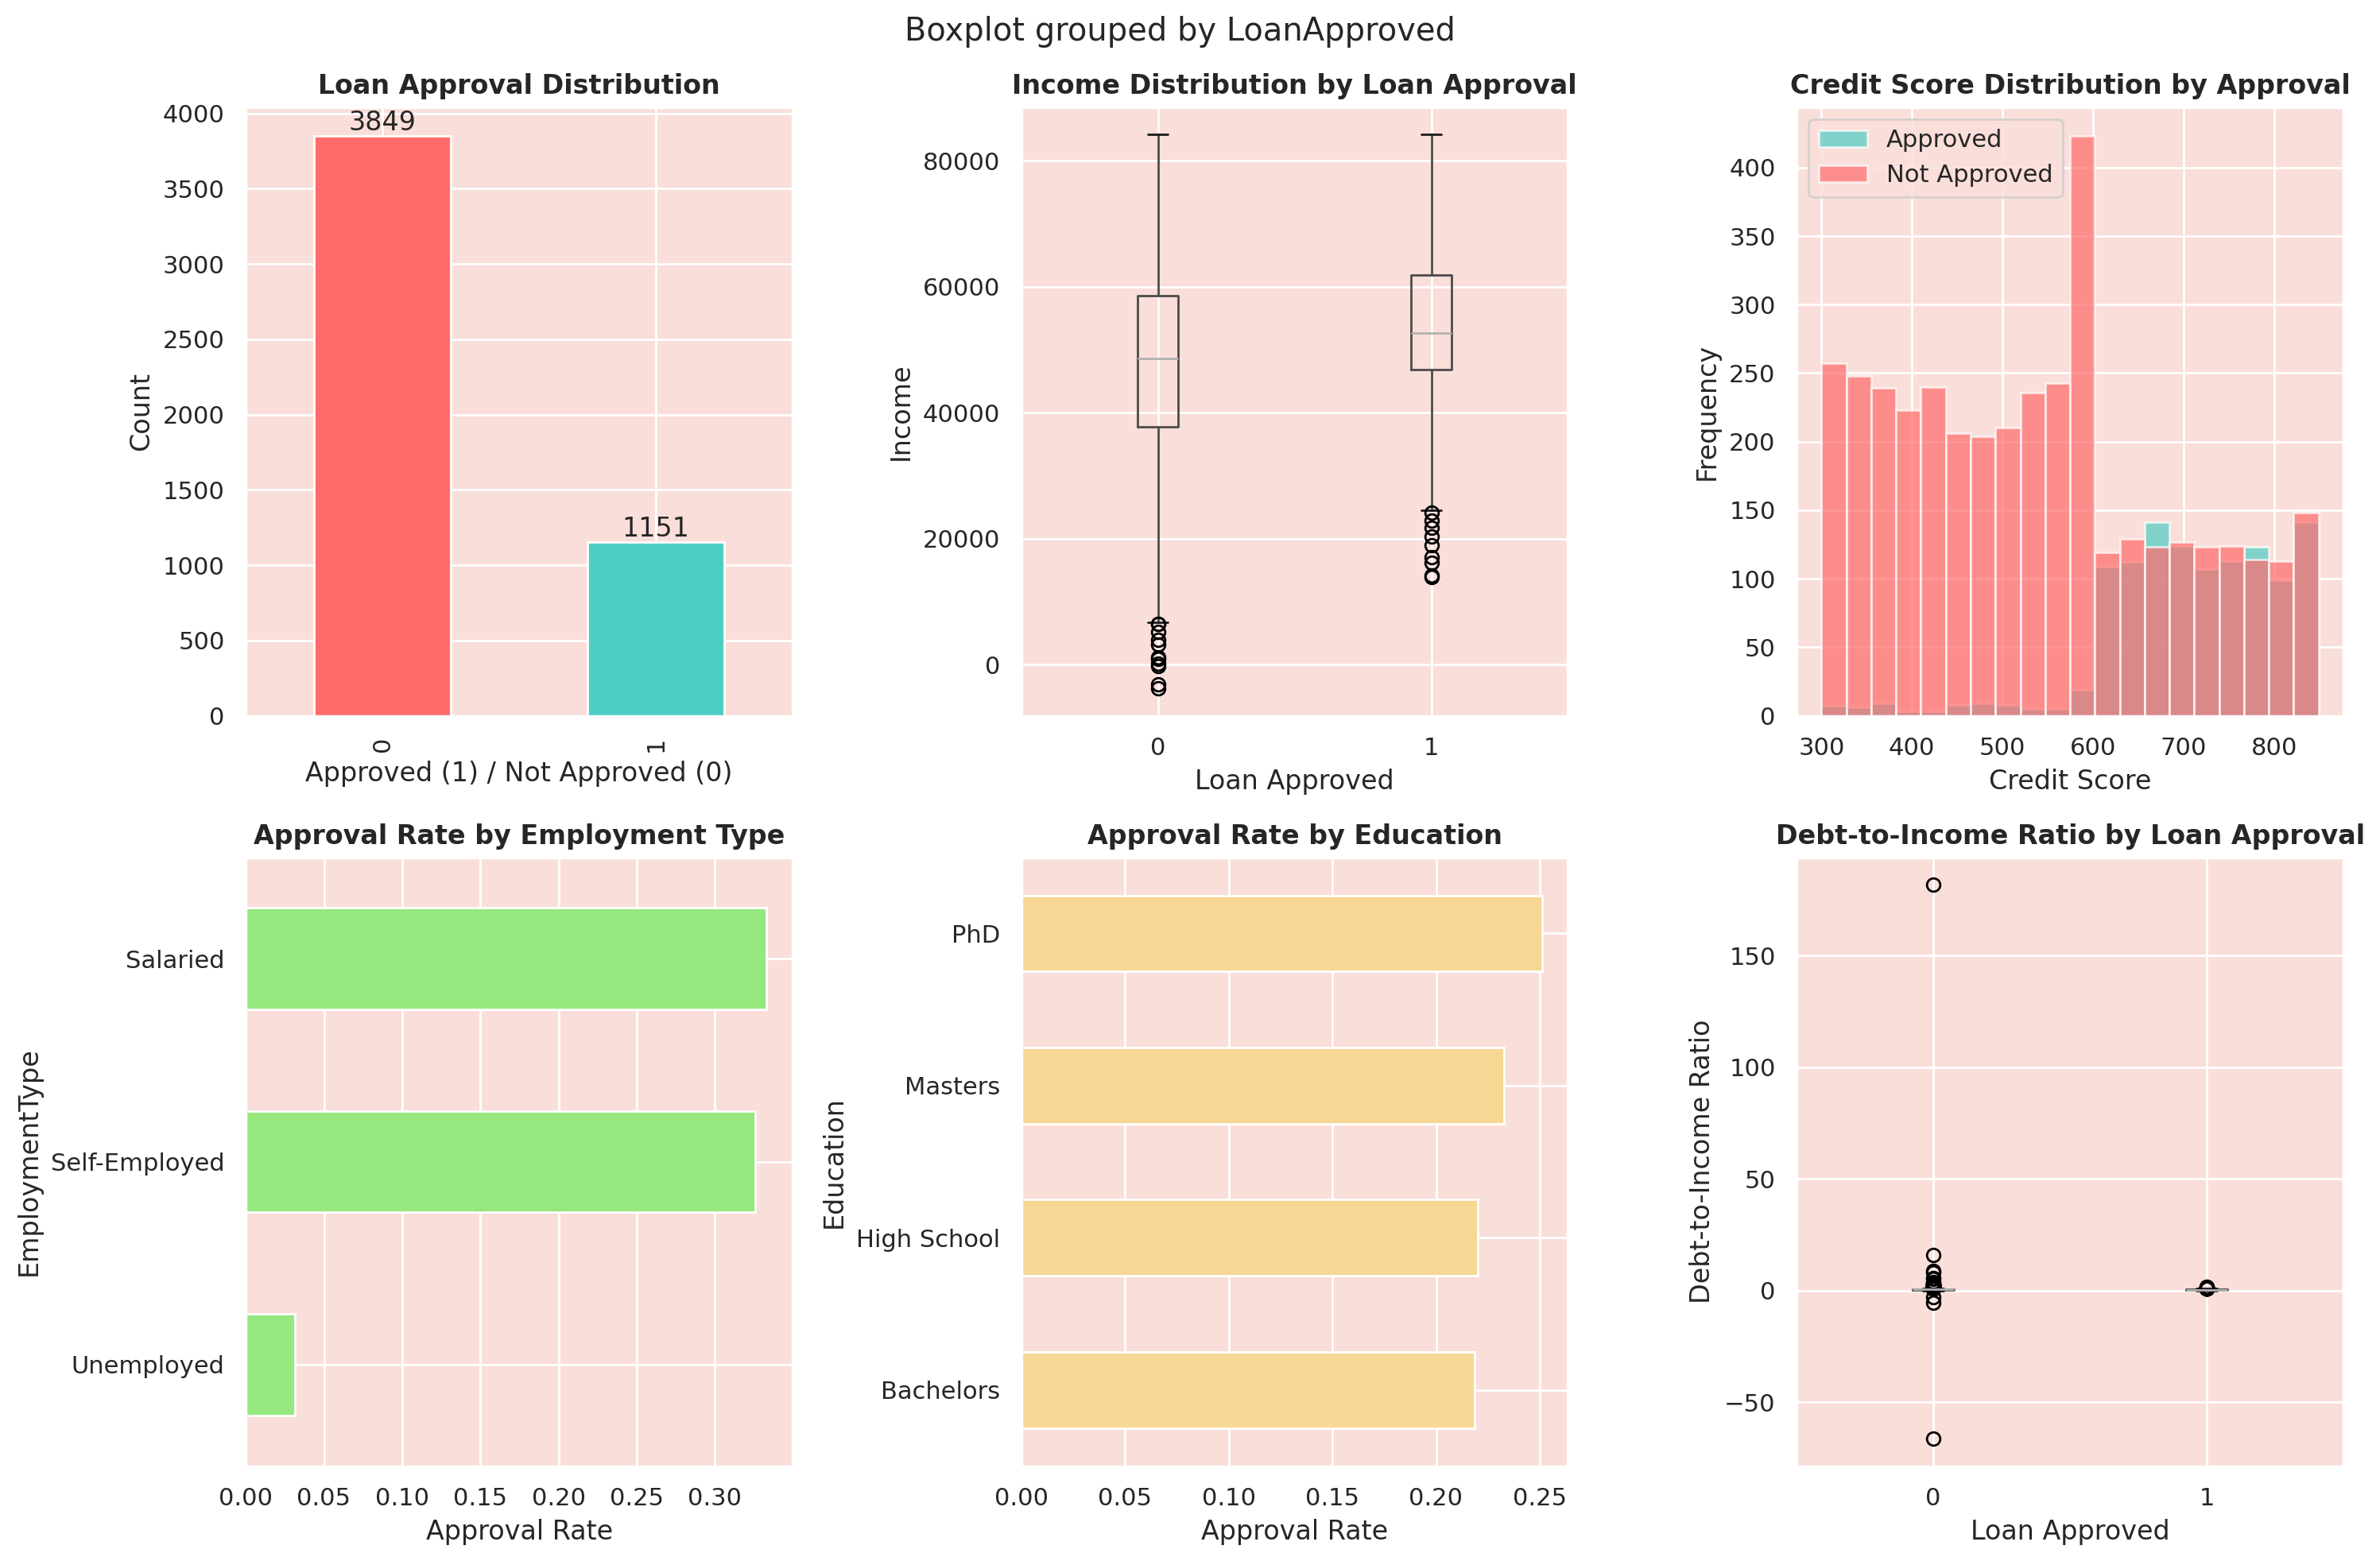

In [30]:
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Target distribution
df_clean['LoanApproved'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#ff6b6b', '#4ecdc4'])
axes[0,0].set_title('Loan Approval Distribution', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Approved (1) / Not Approved (0)')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(df_clean['LoanApproved'].value_counts()):
    axes[0,0].text(i, v, str(v), ha='center', va='bottom')

# 2. Income distribution by approval
df_clean.boxplot(column='Income', by='LoanApproved', ax=axes[0,1])
axes[0,1].set_title('Income Distribution by Loan Approval', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Loan Approved')
axes[0,1].set_ylabel('Income')

# 3. Credit score distribution
df_clean[df_clean['LoanApproved']==1]['CreditScore'].hist(ax=axes[0,2], alpha=0.7, label='Approved', color='#4ecdc4', bins=20)
df_clean[df_clean['LoanApproved']==0]['CreditScore'].hist(ax=axes[0,2], alpha=0.7, label='Not Approved', color='#ff6b6b', bins=20)
axes[0,2].set_title('Credit Score Distribution by Approval', fontsize=12, fontweight='bold')
axes[0,2].set_xlabel('Credit Score')
axes[0,2].set_ylabel('Frequency')
axes[0,2].legend()

# 4. Employment type analysis
approval_by_emp = df_clean.groupby('EmploymentType')['LoanApproved'].mean().sort_values()
approval_by_emp.plot(kind='barh', ax=axes[1,0], color='#95e77e')
axes[1,0].set_title('Approval Rate by Employment Type', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Approval Rate')

# 5. Education analysis
approval_by_edu = df_clean.groupby('Education')['LoanApproved'].mean().sort_values()
approval_by_edu.plot(kind='barh', ax=axes[1,1], color='#f7d794')
axes[1,1].set_title('Approval Rate by Education', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Approval Rate')

# 6. Debt-to-Income ratio by approval
df_clean.boxplot(column='DebtToIncome', by='LoanApproved', ax=axes[1,2])
axes[1,2].set_title('Debt-to-Income Ratio by Loan Approval', fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('Loan Approved')
axes[1,2].set_ylabel('Debt-to-Income Ratio')

plt.tight_layout()
plt.savefig('credit_risk_analysis.png', dpi=100, bbox_inches='tight')
print("📊 Visualization saved as 'credit_risk_analysis.png'")
plt.show()


CORRELATION ANALYSIS

Correlation with Loan Approval:
LoanApproved       1.000000
CreditScore        0.460991
Income             0.188052
LoanAmount         0.015515
YearsExperience   -0.001106
Age               -0.008754
DebtToIncome      -0.017871
Name: LoanApproved, dtype: float64

📊 Heatmap saved as 'correlation_heatmap.png'


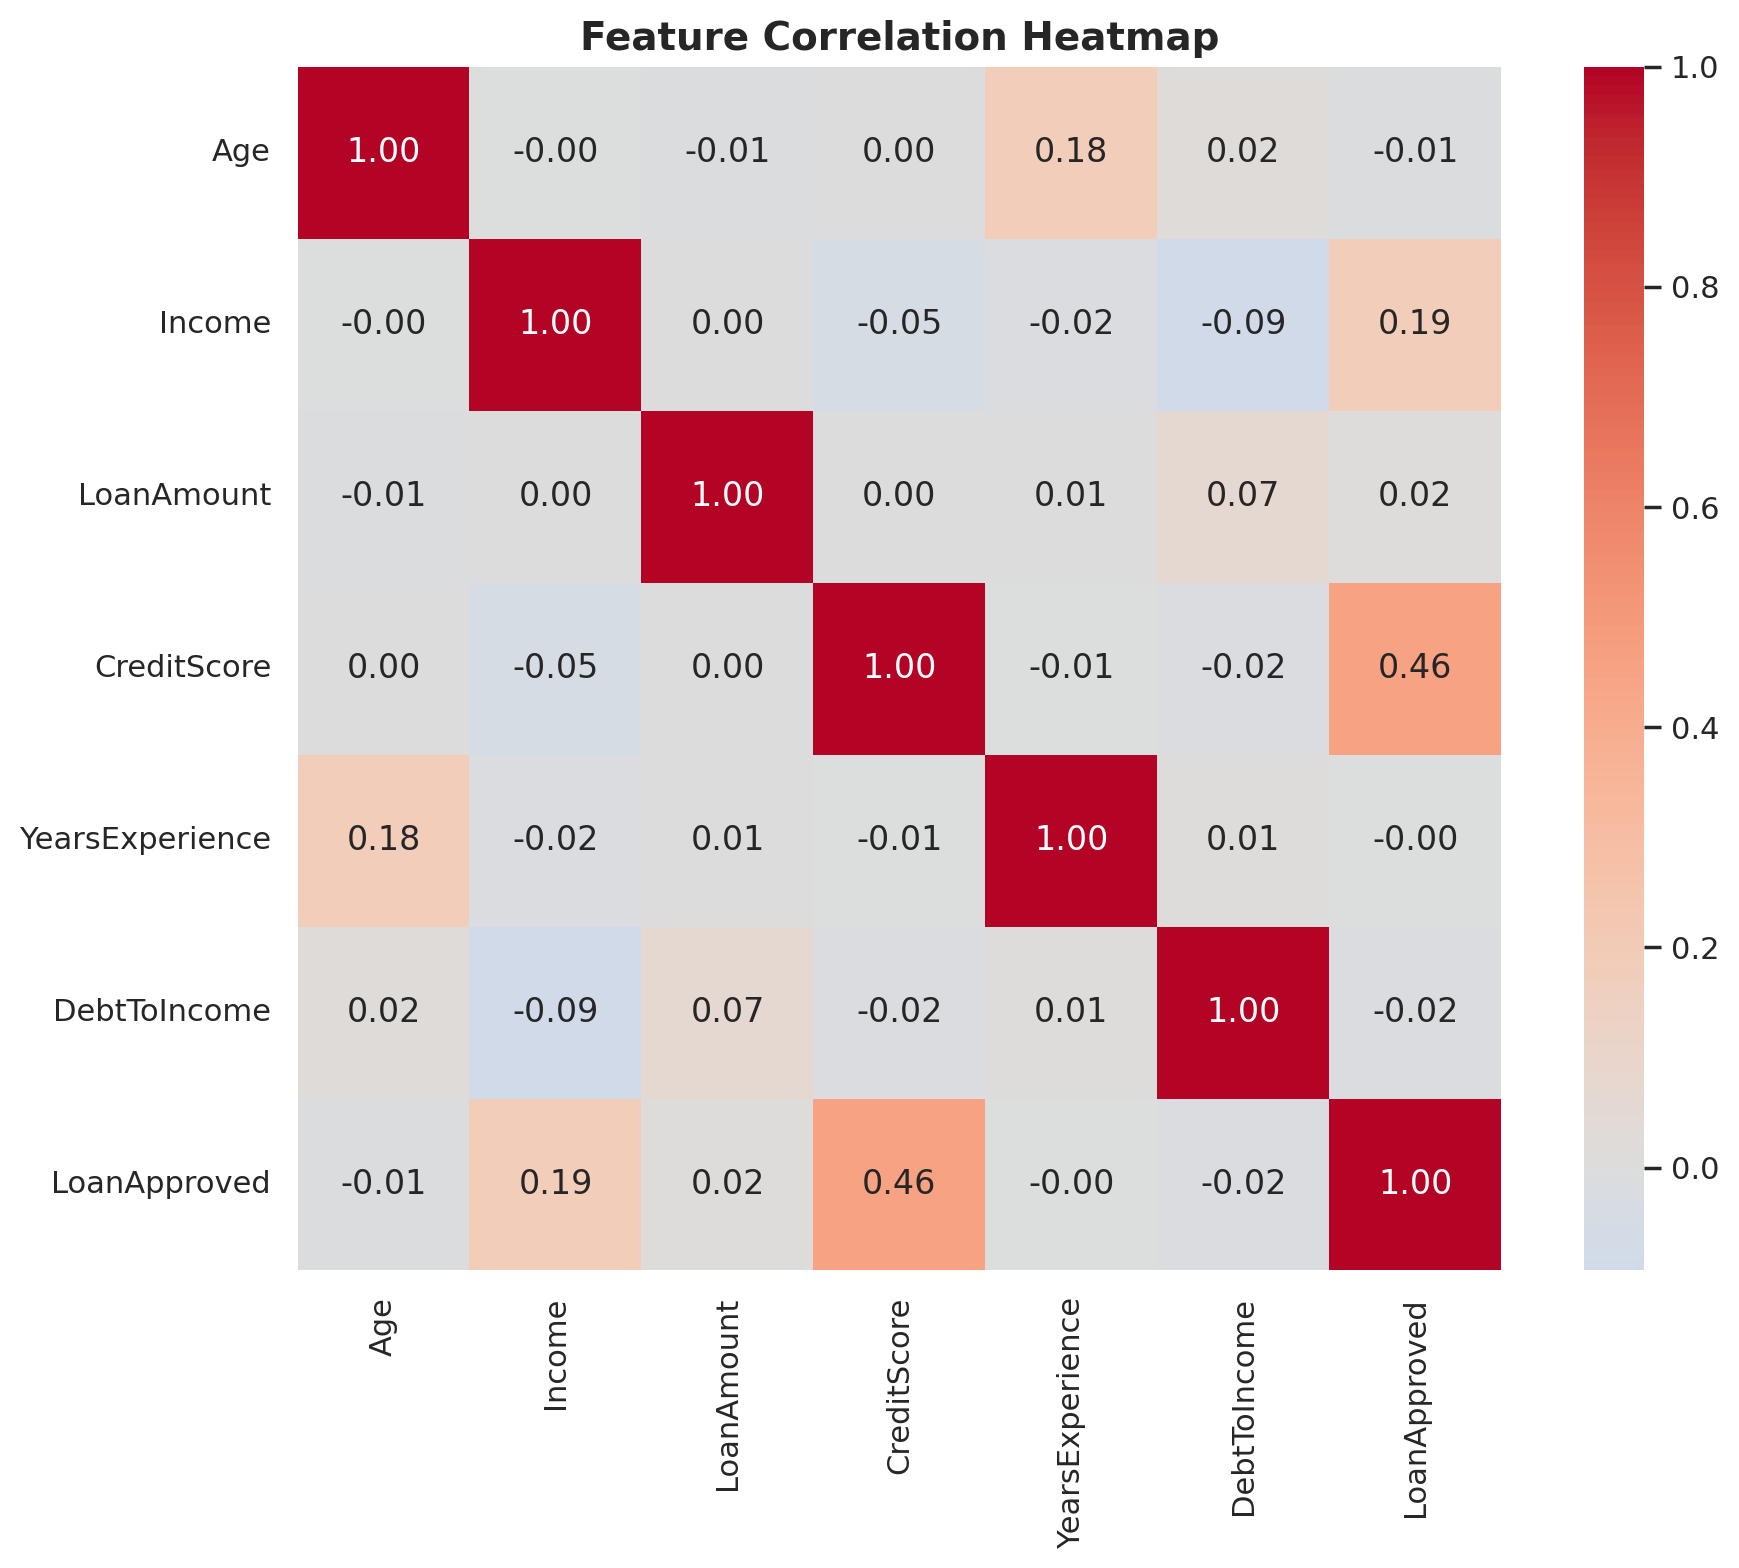

In [31]:
print("\n" + "="*60)
print("CORRELATION ANALYSIS")
print("="*60)

# Select numeric columns for correlation
numeric_features = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience', 'DebtToIncome']
correlation_matrix = df_clean[numeric_features + ['LoanApproved']].corr()

print("\nCorrelation with Loan Approval:")
corr_with_target = correlation_matrix['LoanApproved'].sort_values(ascending=False)
print(corr_with_target)

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
print("\n📊 Heatmap saved as 'correlation_heatmap.png'")
plt.show()


In [32]:
print("\n" + "="*60)
print("MODEL PREPARATION")
print("="*60)

# Prepare features for modeling
df_model = df_clean.copy()

# Encode categorical variables
le_dict = {}
for col in ['Gender', 'Education', 'City', 'EmploymentType', 'AgeGroup', 'IncomeGroup', 'CreditScoreGroup']:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Select features
feature_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience', 
                'DebtToIncome', 'Gender', 'Education', 'EmploymentType', 
                'AgeGroup', 'IncomeGroup', 'CreditScoreGroup']

X = df_model[feature_cols]
y = df_model['LoanApproved']

print(f"\nFeatures selected: {len(feature_cols)}")
print(f"Target shape: {y.shape}")
print(f"Features shape: {X.shape}")

# Checking for any remaining missing values
print(f"\nMissing values in features: {X.isnull().sum().sum()}")
print(f"Missing values in target: {y.isnull().sum()}")


MODEL PREPARATION
Encoded Gender: {'Female': 0, 'Male': 1}
Encoded Education: {'Bachelors': 0, 'High School': 1, 'Masters': 2, 'PhD': 3}
Encoded City: {'Chicago': 0, 'Houston': 1, 'New York': 2, 'San Francisco': 3}
Encoded EmploymentType: {'Salaried': 0, 'Self-Employed': 1, 'Unemployed': 2}
Encoded AgeGroup: {'18-25': 0, '26-35': 1, '36-50': 2, '51-65': 3, '65+': 4}
Encoded IncomeGroup: {'Q1_Low': 0, 'Q2_MedLow': 1, 'Q3_MedHigh': 2, 'Q4_High': 3}
Encoded CreditScoreGroup: {'Excellent': 0, 'Fair': 1, 'Good': 2, 'Poor': 3}

Features selected: 12
Target shape: (5000,)
Features shape: (5000, 12)

Missing values in features: 0
Missing values in target: 0



MODEL TRAINING & EVALUATION
Training set: 4000 samples
Test set: 1000 samples
Train approval rate: 23.03%
Test approval rate: 23.00%

🔧 Training Random Forest Classifier...

Cross-validation ROC-AUC scores: [0.93658244 0.93072417 0.96544149 0.97713156 0.94840694]
Mean CV ROC-AUC: 0.9517 (+/- 0.0348)

📊 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

Not Approved       0.97      0.99      0.98       770
    Approved       0.95      0.89      0.92       230

    accuracy                           0.96      1000
   macro avg       0.96      0.94      0.95      1000
weighted avg       0.96      0.96      0.96      1000


📊 CONFUSION MATRIX:
                     Predicted Not Approved  Predicted Approved
Actual Not Approved                     760                  10
Actual Approved                          26                 204

📊 ROC-AUC SCORE: 0.9333
📊 ROC curve saved as 'roc_curve.png'


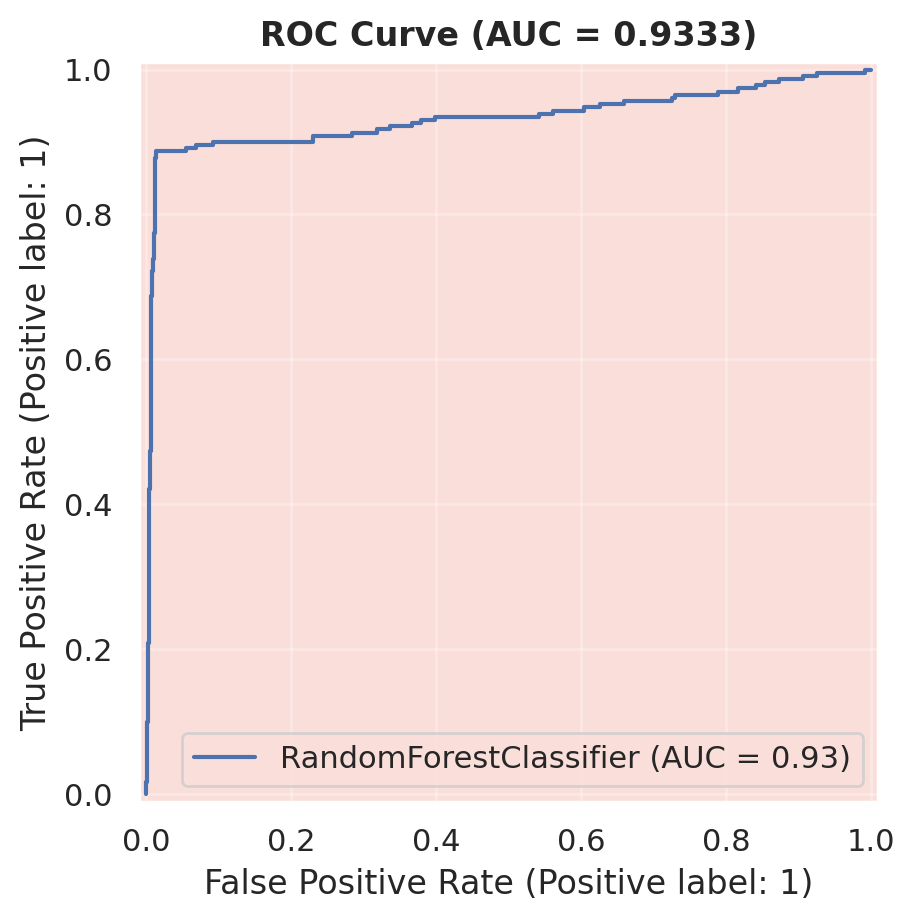

In [33]:
print("\n" + "="*60)
print("MODEL TRAINING & EVALUATION")
print("="*60)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Train approval rate: {y_train.mean()*100:.2f}%")
print(f"Test approval rate: {y_test.mean()*100:.2f}%")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Random Forest with class balancing
print("\n🔧 Training Random Forest Classifier...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

# Cross-validation
cv_scores = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
print(f"\nCross-validation ROC-AUC scores: {cv_scores}")
print(f"Mean CV ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# Predictions
y_pred = rf_model.predict(X_test_scaled)
y_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
print("\n📊 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Not Approved', 'Approved']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n📊 CONFUSION MATRIX:")
print(pd.DataFrame(cm, index=['Actual Not Approved', 'Actual Approved'], 
                   columns=['Predicted Not Approved', 'Predicted Approved']))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print(f"\n📊 ROC-AUC SCORE: {roc_auc:.4f}")

# Plot ROC Curve
RocCurveDisplay.from_estimator(rf_model, X_test_scaled, y_test)
plt.title(f'ROC Curve (AUC = {roc_auc:.4f})', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.savefig('roc_curve.png', dpi=100, bbox_inches='tight')
print("📊 ROC curve saved as 'roc_curve.png'")
plt.show()



FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features:
             Feature  Importance
3        CreditScore    0.400737
8     EmploymentType    0.216775
11  CreditScoreGroup    0.133014
1             Income    0.120030
10       IncomeGroup    0.063736
5       DebtToIncome    0.021583
2         LoanAmount    0.014215
0                Age    0.011857
4    YearsExperience    0.009048
9           AgeGroup    0.003705
📊 Feature importance plot saved as 'feature_importance.png'


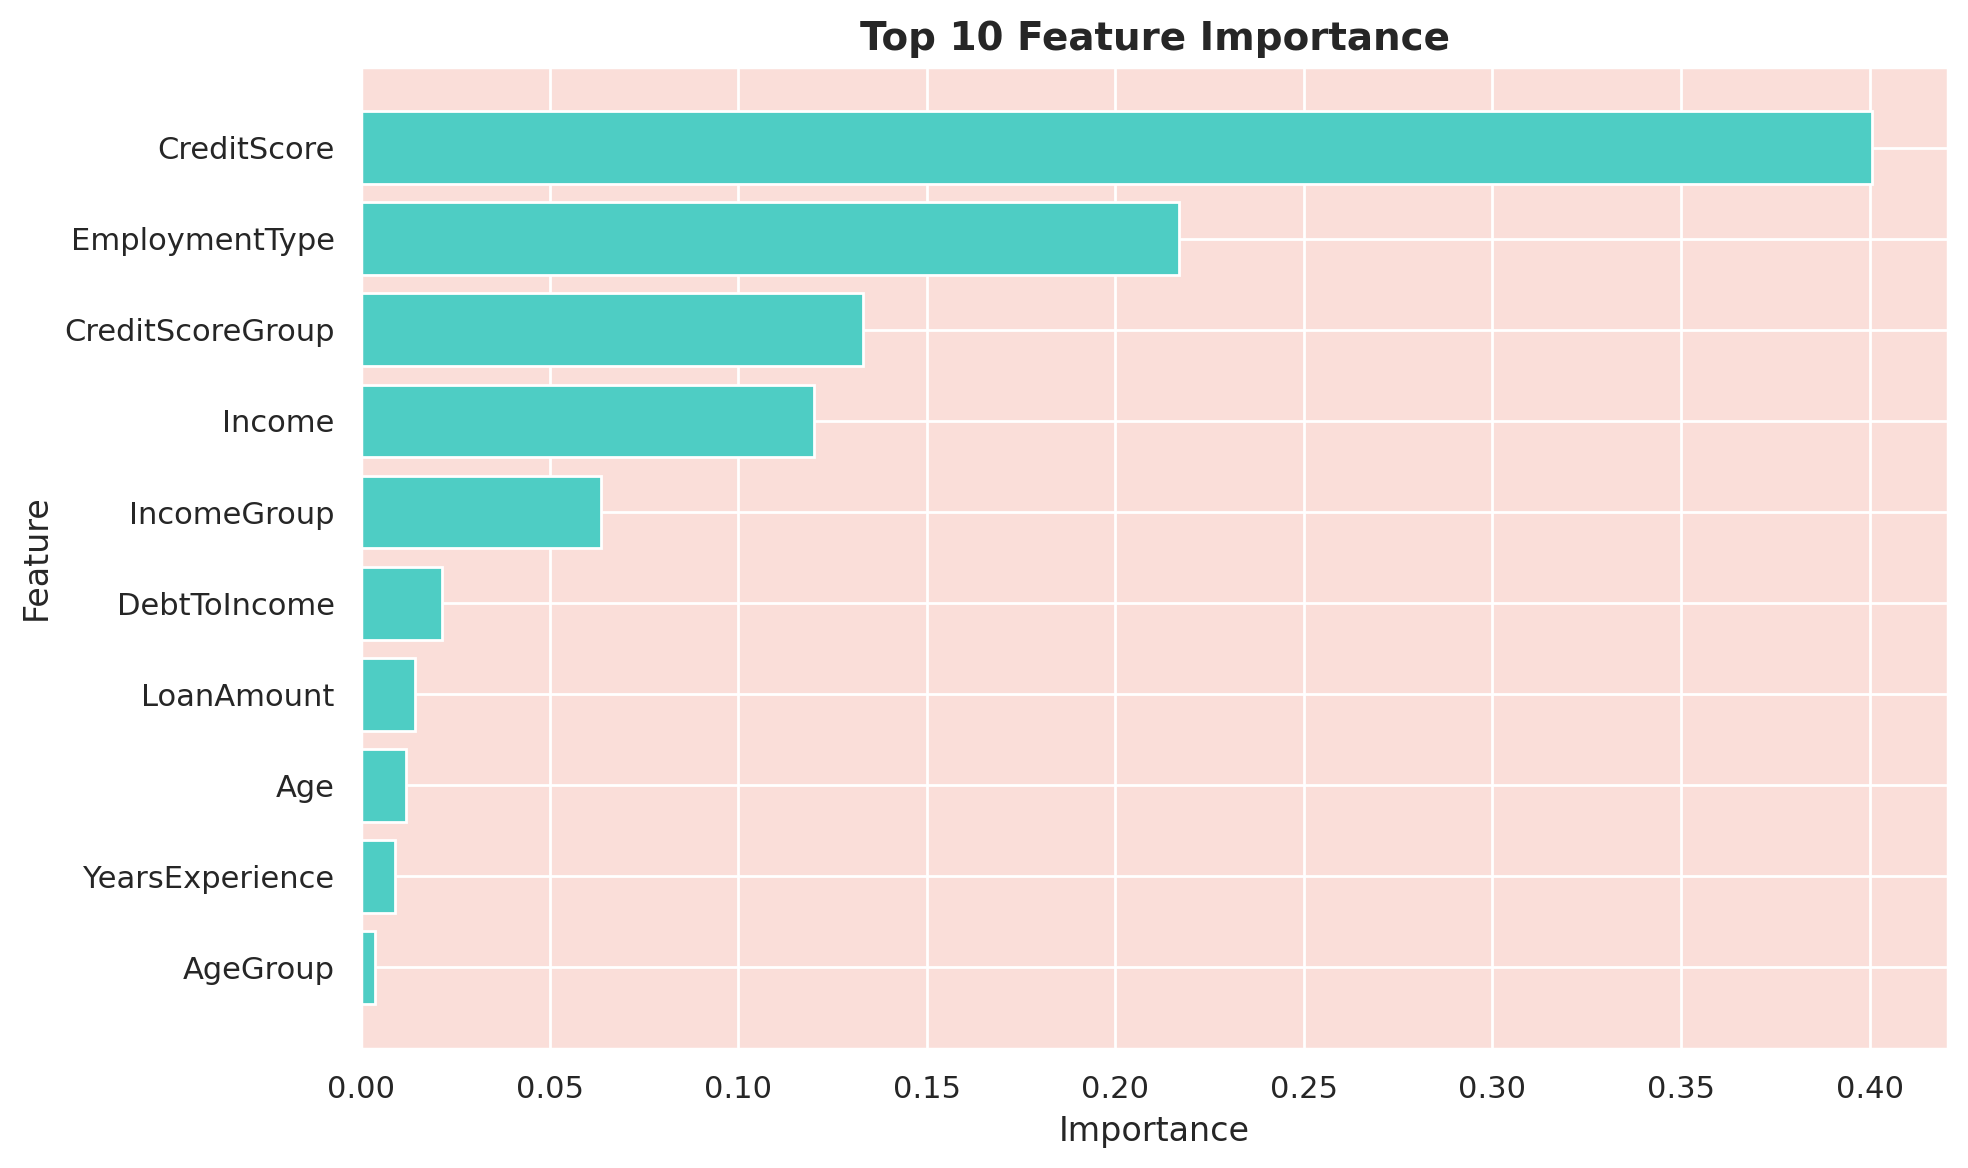

In [34]:
print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'][:10], feature_importance['Importance'][:10], color='#4ecdc4')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Top 10 Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
print("📊 Feature importance plot saved as 'feature_importance.png'")
plt.show()

In [40]:
print("\n" + "="*60)
print("SUMMARY REPORT")
print("="*60)

print(f"""
DATASET SUMMARY:
- Total samples: {len(df)}
- Features: {len(df.columns)}
- Target classes: {df['LoanApproved'].nunique()}
- Missing values handled: {missing.sum()}
- Negative loan amounts fixed: {neg_loans}

MODEL PERFORMANCE:
- ROC-AUC Score: {roc_auc:.4f}
- Cross-validation ROC-AUC: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})

KEY INSIGHTS:
1. Top predictor: {feature_importance.iloc[0]['Feature']} (importance: {feature_importance.iloc[0]['Importance']:.3f})
2. Approval rate: {df['LoanApproved'].mean()*100:.1f}%
3. Most important factors: CreditScore, Income, LoanAmount, DebtToIncome
""")

print("\n✅ Analysis complete! Visualizations saved:")
print("   - credit_risk_analysis.png")
print("   - correlation_heatmap.png")
print("   - roc_curve.png")
print("   - feature_importance.png")
print(f"\nCleaned dataset shape: {df_clean.shape}")
print("\n" + "="*60)


SUMMARY REPORT

DATASET SUMMARY:
- Total samples: 5000
- Features: 10
- Target classes: 2
- Missing values handled: 588
- Negative loan amounts fixed: 28

MODEL PERFORMANCE:
- ROC-AUC Score: 0.9333
- Cross-validation ROC-AUC: 0.9517 (+/- 0.0348)

KEY INSIGHTS:
1. Top predictor: CreditScore (importance: 0.401)
2. Approval rate: 23.0%
3. Most important factors: CreditScore, Income, LoanAmount, DebtToIncome


✅ Analysis complete! Visualizations saved:
   - credit_risk_analysis.png
   - correlation_heatmap.png
   - roc_curve.png
   - feature_importance.png

Cleaned dataset shape: (5000, 14)

